# TP3 – Image Captioning com CLIP + SmolLM2

**Pipeline:** CLIP ViT-B/32 (encoder, congelado) → Projetor Linear/MLP → SmolLM2-135M (LLM, congelado)

**Tarefa:** Gerar legendas em inglês para imagens do Flickr8k

**Hardware:** CPU

| Componente | Modelo | Parâmetros treináveis |
|---|---|---|
| Encoder visual | CLIP ViT-B/32 | 0 (congelado) |
| **Projetor** | **Linear 512→576** | **~295K** |
| LLM | SmolLM2-135M-Instruct | 0 (congelado) |

In [21]:
# Descomentar para instalar dependencias
!pip install transformers datasets torch pillow evaluate rouge_score tqdm matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [22]:
import os
import pickle
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import CLIPProcessor, CLIPModel, AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from evaluate import load as load_metric
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import display

# Configuracao
CLIP_MODEL  = 'openai/clip-vit-base-patch32'
LLM_MODEL   = 'HuggingFaceTB/SmolLM2-135M-Instruct'
DATASET     = 'jxie/flickr8k'
CACHE_FILE  = 'clip_features.pkl'
CKPT_DIR    = 'checkpoints'

SUBSET      = True   # False = dataset completo (muito mais lento em CPU)
N_TRAIN     = 2000
N_VAL       = 400
N_TEST      = 400

MAX_LEN     = 64
BATCH_SIZE  = 8
EPOCHS      = 5
LR          = 1e-3
CLIP_DIM    = 512

os.makedirs(CKPT_DIR, exist_ok=True)
device = torch.device('cpu')
print(f'Device: {device}')

Device: cpu


## 1. Dataset – Flickr8k

In [23]:
ds = load_dataset(DATASET)
print(ds)

sample0  = ds['train'][0]
IMG_COL  = 'image'
# Flickr8k tem 5 colunas de caption: caption_0 a caption_4
CAP_COLS = sorted([k for k in ds['train'].features if k.startswith('caption_')])
print(f'Colunas de caption detectadas: {CAP_COLS}')
print(f'Exemplo (caption_0): {sample0[CAP_COLS[0]]}')

split_train = ds['train'].select(range(N_TRAIN)) if SUBSET else ds['train']
split_val   = ds['validation'].select(range(N_VAL))   if SUBSET else ds['validation']
split_test  = ds['test'].select(range(N_TEST))    if SUBSET else ds['test']

print(f'Tamanhos: train={len(split_train)}, val={len(split_val)}, test={len(split_test)}')

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})
Colunas de caption detectadas: ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']
Exemplo (caption_0): A black dog is running after a white dog in the snow .
Tamanhos: train=2000, val=400, test=400


## 2. Encoder Visual – CLIP (congelado)

Extraimos as features uma unica vez e guardamos em cache — poupa muito tempo em CPU.

In [24]:
clip_model     = CLIPModel.from_pretrained(CLIP_MODEL)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL)
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad_(False)

n_clip = sum(p.numel() for p in clip_model.parameters())
print(f'CLIP carregado: {n_clip:,} parametros (todos congelados)')


def extract_clip_features(split, desc=''):
    feats = []
    for s in tqdm(split, desc=f'CLIP features {desc}'):
        with torch.no_grad():
            inp          = clip_processor(images=s[IMG_COL], return_tensors='pt')
            vision_out   = clip_model.vision_model(pixel_values=inp['pixel_values'])
            feat         = clip_model.visual_projection(vision_out.pooler_output).squeeze(0)  # [512]
        feats.append(feat)
    return feats


if os.path.exists(CACHE_FILE):
    print('Cache encontrado – a carregar features...')
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
else:
    print('Primeira execucao – a extrair features (pode demorar)...')
    cache = {
        'train': extract_clip_features(split_train, 'train'),
        'val':   extract_clip_features(split_val,   'val'),
        'test':  extract_clip_features(split_test,  'test'),
    }
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(cache, f)
    print(f'Cache guardado em {CACHE_FILE}')

train_feats = cache['train']
val_feats   = cache['val']
test_feats  = cache['test']
print(f'Feature shape: {train_feats[0].shape}')  # esperado: torch.Size([512])

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP carregado: 151,277,313 parametros (todos congelados)
Cache encontrado – a carregar features...
Feature shape: torch.Size([512])


## 3. Language Model – SmolLM2-135M (congelado)

In [25]:
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# torch_dtype=float32: SmolLM2 carrega em bfloat16 por defeito,
# mas bfloat16 em CPU e lento e causa conflitos com o projetor (float32)
llm = AutoModelForCausalLM.from_pretrained(LLM_MODEL, torch_dtype=torch.float32)
llm.eval()
for p in llm.parameters():
    p.requires_grad_(False)

LLM_DIM     = llm.config.hidden_size
embed_layer = llm.get_input_embeddings()

n_llm = sum(p.numel() for p in llm.parameters())
print(f'SmolLM2 carregado: {n_llm:,} parametros (todos congelados, float32)')
print(f'hidden_size = {LLM_DIM}')  # esperado: 576

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

SmolLM2 carregado: 134,515,008 parametros (todos congelados, float32)
hidden_size = 576


## 4. Projetor – alinha o espaco visual com o espaco do LLM

O projetor e o **unico modulo trainavel**. Mapeia embeddings CLIP (512 dims) para o espaco SmolLM2 (576 dims).

- **Linear**: `nn.Linear(512, 576)` — ~295K parametros
- **MLP**: duas camadas com GELU — ~1.6M parametros

In [26]:
class LinearProjector(nn.Module):
    def __init__(self, clip_dim=512, llm_dim=576):
        super().__init__()
        self.proj = nn.Linear(clip_dim, llm_dim)

    def forward(self, x):
        return self.proj(x)


class MLPProjector(nn.Module):
    def __init__(self, clip_dim=512, hidden=1024, llm_dim=576):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(clip_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, llm_dim),
        )

    def forward(self, x):
        return self.proj(x)


proj_linear = LinearProjector(CLIP_DIM, LLM_DIM)
proj_mlp    = MLPProjector(CLIP_DIM, 1024, LLM_DIM)

n_lin = sum(p.numel() for p in proj_linear.parameters())
n_mlp = sum(p.numel() for p in proj_mlp.parameters())
print(f'Linear projector : {n_lin:,} parametros treinaveis')
print(f'MLP projector    : {n_mlp:,} parametros treinaveis')

Linear projector : 295,488 parametros treinaveis
MLP projector    : 1,115,712 parametros treinaveis


## 5. Dataset PyTorch e DataLoaders

In [27]:
class CaptionDataset(Dataset):
    def __init__(self, features, captions, tokenizer, max_len=64):
        self.features  = features
        self.captions  = captions
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, idx):
        feat = self.features[idx]
        cap  = self.captions[idx]
        enc  = self.tokenizer(
            cap,
            return_tensors='pt',
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
        )
        return feat, enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)


# Para treino/val: apenas caption_0 (uma por imagem, suficiente)
train_caps = [s[CAP_COLS[0]] for s in split_train]
val_caps   = [s[CAP_COLS[0]] for s in split_val]

# Para avaliacao BLEU: todas as 5 captions como referencia (padrao Flickr8k)
test_all_caps = [[s[c] for c in CAP_COLS] for s in split_test]
test_caps     = [caps[0] for caps in test_all_caps]  # apenas para display

train_ds = CaptionDataset(train_feats, train_caps, tokenizer, MAX_LEN)
val_ds   = CaptionDataset(val_feats,   val_caps,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 250 | Val batches: 50


## 6. Loop de Treino

**Sequencia de entrada:** `[visual_embed | text_embeds]`

**Labels:** `[-100 | token_ids]` — o -100 faz com que o loss ignore a posicao visual. O LLM aprende a prever a legenda a partir do embedding visual.

In [28]:
def train_epoch(projector, loader, optimizer):
    projector.train()
    total = 0.0
    for clip_feat, input_ids, attn_mask in tqdm(loader, leave=False, desc='  treino'):
        optimizer.zero_grad()

        # Embedding visual: [B, 512] -> [B, 1, LLM_DIM]
        vis_emb = projector(clip_feat).unsqueeze(1)

        # Embeddings do texto: [B, T, LLM_DIM] (sem gradiente)
        with torch.no_grad():
            txt_emb = embed_layer(input_ids)

        # Sequencia combinada: [B, T+1, LLM_DIM]
        inputs_embeds = torch.cat([vis_emb, txt_emb], dim=1)

        # Labels: -100 na posicao visual; mascarar padding
        vis_lbl  = torch.full((input_ids.size(0), 1), -100, dtype=torch.long)
        txt_lbl  = input_ids.clone()
        txt_lbl[attn_mask == 0] = -100
        labels   = torch.cat([vis_lbl, txt_lbl], dim=1)  # [B, T+1]

        # Attention mask estendida para o token visual
        vis_mask  = torch.ones(attn_mask.size(0), 1, dtype=attn_mask.dtype)
        full_mask = torch.cat([vis_mask, attn_mask], dim=1)  # [B, T+1]

        out  = llm(inputs_embeds=inputs_embeds, attention_mask=full_mask, labels=labels)
        loss = out.loss
        loss.backward()
        optimizer.step()
        total += loss.item()

    return total / len(loader)


@torch.no_grad()
def eval_loss(projector, loader):
    projector.eval()
    total = 0.0
    for clip_feat, input_ids, attn_mask in loader:
        vis_emb       = projector(clip_feat).unsqueeze(1)
        txt_emb       = embed_layer(input_ids)
        inputs_embeds = torch.cat([vis_emb, txt_emb], dim=1)

        vis_lbl  = torch.full((input_ids.size(0), 1), -100, dtype=torch.long)
        txt_lbl  = input_ids.clone()
        txt_lbl[attn_mask == 0] = -100
        labels   = torch.cat([vis_lbl, txt_lbl], dim=1)

        vis_mask  = torch.ones(attn_mask.size(0), 1, dtype=attn_mask.dtype)
        full_mask = torch.cat([vis_mask, attn_mask], dim=1)

        out    = llm(inputs_embeds=inputs_embeds, attention_mask=full_mask, labels=labels)
        total += out.loss.item()

    return total / len(loader)


def run_training(projector, name):
    optimizer = torch.optim.AdamW(projector.parameters(), lr=LR)
    t_losses, v_losses = [], []

    for epoch in range(EPOCHS):
        t = train_epoch(projector, train_loader, optimizer)
        v = eval_loss(projector, val_loader)
        t_losses.append(t)
        v_losses.append(v)
        print(f'[{name}] epoch {epoch+1}/{EPOCHS}  train={t:.4f}  val={v:.4f}')

    torch.save(projector.state_dict(), f'{CKPT_DIR}/{name}.pt')
    return t_losses, v_losses

## 7. Treinar Projetor Linear

  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[linear] epoch 1/5  train=5.2508  val=5.1842


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[linear] epoch 2/5  train=5.2087  val=5.2817


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[linear] epoch 3/5  train=5.1365  val=4.8786


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[linear] epoch 4/5  train=4.7401  val=4.6338


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[linear] epoch 5/5  train=4.5533  val=4.4997


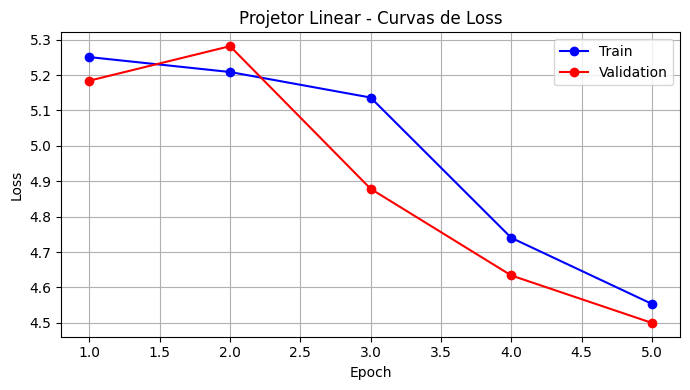

In [29]:
tl_lin, vl_lin = run_training(proj_linear, 'linear')

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), tl_lin, 'b-o', label='Train')
plt.plot(range(1, EPOCHS+1), vl_lin, 'r-o', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Projetor Linear - Curvas de Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_linear.png', dpi=150)
plt.show()

## 8. Geracao de Legendas (greedy decoding)

Referencia : The dogs are in the snow in front of a fence .
Gerado     : 

I'm so glad you're doing well. I've been thinking about you a lot lately, and I'm really glad we're on the same page. I've been working on a new


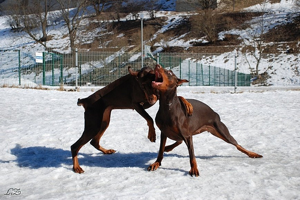

In [30]:
@torch.no_grad()
def generate_caption(clip_feat, projector, max_new_tokens=40):
    projector.eval()
    vis = projector(clip_feat.unsqueeze(0)).unsqueeze(1)  # [1, 1, LLM_DIM]

    current_embeds = vis
    generated_ids  = []

    for _ in range(max_new_tokens):
        out      = llm(inputs_embeds=current_embeds)
        next_tok = out.logits[:, -1, :].argmax(-1, keepdim=True)  # [1, 1]
        tok_id   = next_tok.item()

        if tok_id in {tokenizer.eos_token_id, tokenizer.pad_token_id}:
            break

        generated_ids.append(tok_id)
        next_emb       = embed_layer(next_tok)  # [1, 1, LLM_DIM]
        current_embeds = torch.cat([current_embeds, next_emb], dim=1)

    return tokenizer.decode(generated_ids, skip_special_tokens=True)


# Teste rapido
pred0 = generate_caption(test_feats[0], proj_linear)
print(f'Referencia : {test_caps[0]}')
print(f'Gerado     : {pred0}')
display(split_test[0][IMG_COL].resize((300, 200)))

## 9. Avaliacao Quantitativa – BLEU-4 e ROUGE-L

In [31]:
bleu_metric  = load_metric('bleu')
rouge_metric = load_metric('rouge')


def evaluate_projector(projector, feats, all_caps, name=''):
    """all_caps: lista de listas (5 refs por imagem) ou lista de strings (1 ref)."""
    preds, refs = [], []
    for feat, caps in tqdm(zip(feats, all_caps), total=len(all_caps), desc=f'Avaliando {name}'):
        pred = generate_caption(feat, projector)
        preds.append(pred)
        refs.append(caps if isinstance(caps, list) else [caps])

    bleu  = bleu_metric.compute(predictions=preds, references=refs)
    rouge = rouge_metric.compute(predictions=preds, references=[r[0] for r in refs])

    return {'bleu4': bleu['bleu'], 'rougeL': rouge['rougeL'], 'preds': preds, 'refs': refs}


res_lin = evaluate_projector(proj_linear, test_feats, test_all_caps, 'Linear')
print(f'Linear  BLEU-4={res_lin["bleu4"]:.4f}  ROUGE-L={res_lin["rougeL"]:.4f}')

Avaliando Linear:   0%|          | 0/400 [00:00<?, ?it/s]

Linear  BLEU-4=0.0000  ROUGE-L=0.0521


## 10. Analise Qualitativa


------------------------------------------------------------
Exemplos - Projetor Linear
------------------------------------------------------------
Ref  : A black dog is looking at the ball on the beach by the ocean .
Pred : 

I'm so glad you're doing well. I've been thinking about you a lot lately, and I'm excited to hear about your new job. I've been working with a local non



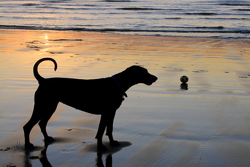

Ref  : A boy climbing a rocky area .
Pred : 1234567890123456789012345678901234567890



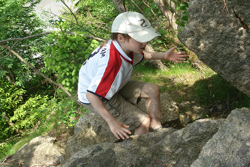

Ref  : A man dressed in grey climbing a large brown rock .
Pred : 1111111111111111111111111111111111111111



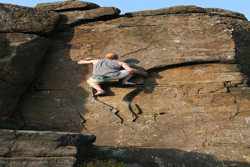

Ref  : A bunch of asian children on steps .
Pred :  dock, and a few other items.

The dock is a sturdy, 12-foot-long wooden structure that's been in the shop for years. It's made of solid oak



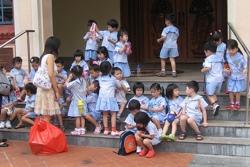

Ref  : A group of people are gathered on a white pillared porch for a photo .
Pred : 1234567890123456789012345678901234567890



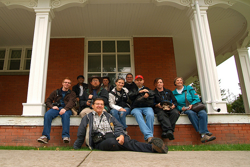

In [32]:
def show_examples(results, split, n=5, title=''):
    print(f'\n{"-"*60}\n{title}\n{"-"*60}')
    indices = random.sample(range(len(results['preds'])), min(n, len(results['preds'])))
    for i in indices:
        ref  = results['refs'][i][0]
        pred = results['preds'][i]
        print(f'Ref  : {ref}')
        print(f'Pred : {pred}\n')
        display(split[i][IMG_COL].resize((250, 167)))

show_examples(res_lin, split_test, n=5, title='Exemplos - Projetor Linear')

## 11. Treinar Projetor MLP e Comparar

  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[mlp] epoch 1/5  train=4.4037  val=4.1166


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[mlp] epoch 2/5  train=3.8793  val=3.6518


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[mlp] epoch 3/5  train=3.5574  val=3.5359


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[mlp] epoch 4/5  train=3.4725  val=3.4681


  treino:   0%|          | 0/250 [00:00<?, ?it/s]

[mlp] epoch 5/5  train=3.4044  val=3.4337


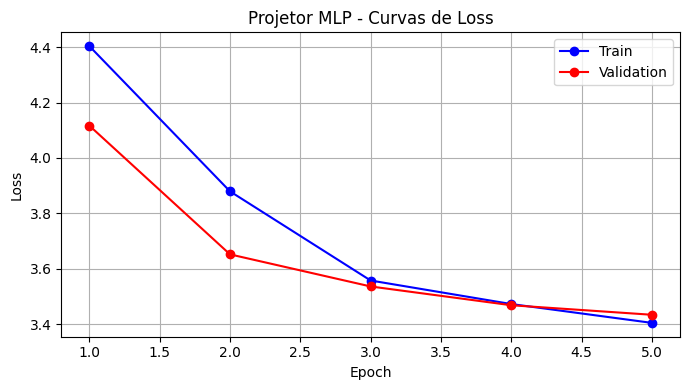

In [33]:
tl_mlp, vl_mlp = run_training(proj_mlp, 'mlp')

plt.figure(figsize=(7, 4))
plt.plot(range(1, EPOCHS+1), tl_mlp, 'b-o', label='Train')
plt.plot(range(1, EPOCHS+1), vl_mlp, 'r-o', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Projetor MLP - Curvas de Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_mlp.png', dpi=150)
plt.show()

In [34]:
res_mlp = evaluate_projector(proj_mlp, test_feats, test_all_caps, 'MLP')

print('=' * 50)
print(f'{"Projetor":<10} | {"BLEU-4":>8} | {"ROUGE-L":>8}')
print('-' * 50)
print(f'{"Linear":<10} | {res_lin["bleu4"]:>8.4f} | {res_lin["rougeL"]:>8.4f}')
print(f'{"MLP":<10} | {res_mlp["bleu4"]:>8.4f} | {res_mlp["rougeL"]:>8.4f}')
print('=' * 50)

Avaliando MLP:   0%|          | 0/400 [00:00<?, ?it/s]

Projetor   |   BLEU-4 |  ROUGE-L
--------------------------------------------------
Linear     |   0.0000 |   0.0521
MLP        |   0.0000 |   0.1023


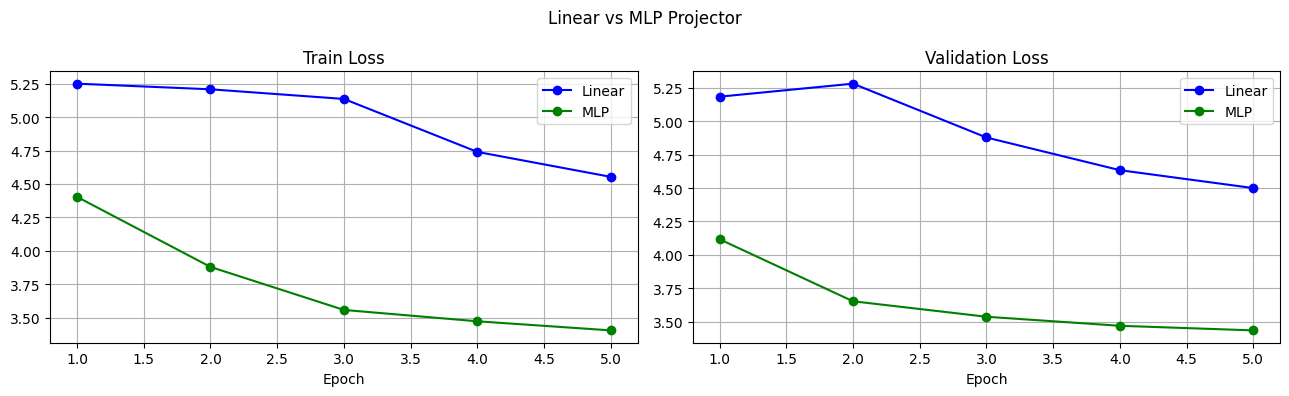

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)

ax1.plot(ep, tl_lin, 'b-o', label='Linear')
ax1.plot(ep, tl_mlp, 'g-o', label='MLP')
ax1.set_title('Train Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(ep, vl_lin, 'b-o', label='Linear')
ax2.plot(ep, vl_mlp, 'g-o', label='MLP')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('Linear vs MLP Projector')
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=150)
plt.show()

## Notas para o Artigo

- Preencher a tabela de resultados em `artigo.md` com os valores BLEU-4 e ROUGE-L acima.
- Os graficos foram guardados em `loss_linear.png`, `loss_mlp.png`, `loss_comparison.png`.
- Selecionar 2-3 exemplos bons e maus da secao 10 para incluir no artigo.
- Comentar se MLP > Linear e porque (mais capacidade de expressao? overfitting?).